In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [ ]:
Dataset = 'Max_lrDMS' # 'Rike_high_confidence'|'Rike_low_confidence'|'Simon_ML'|'Simon_ML+Michal_neg'|'Max_lrDMS'

data_dir = f'/content/drive/MyDrive/Xai_ired/Data/{Dataset}/data_processed.csv'
nham_aa_name = 'Nham_aa'
fitness_name = 'fitness'
variant_name = 'mut'
variant_split_symbol = '-'
threshold_pos = -9.9

# Quantify point mutation effect

In [ ]:
df = pd.read_csv(data_dir)
if nham_aa_name not in df.columns:
    df[nham_aa_name] = df[variant_name].apply(lambda x: len(x.split(variant_split_symbol)))
    df.loc[df[variant_name] == 'WT', nham_aa_name] = 0
point_mut_dic = dict()
df_point_mut = df[df[nham_aa_name] == 1]
df_point_mut_pos = df_point_mut[df_point_mut[fitness_name] > threshold_pos]
print(f'total number of point mutations: {len(df_point_mut)}')
print(f'total number of point mutations with measurable fitness: {len(df_point_mut_pos)}')
point_mut_dic = dict(zip(df_point_mut_pos[variant_name], df_point_mut_pos[fitness_name]))

total number of point mutations: 1207
total number of point mutations with measurable fitness: 1207


# Observe the correlation between real point mutation effect and that averaged from all variants containing that point mutation

In [ ]:
df_pos = df[df[fitness_name] > threshold_pos].reset_index(drop=True)
print(f'total number of variants with measurable fitness: {len(df_pos)}')
point_mut_sample_size_dic = defaultdict(lambda: 0)
point_mut_average_effect_dic = defaultdict(lambda: 0)
for i in range(len(df_pos)):
    muts = df.loc[i, variant_name].split(variant_split_symbol)
    fit = df.loc[i, fitness_name]
    for mut in muts:
        if mut in point_mut_dic:
            point_mut_sample_size_dic[mut] += 1
            point_mut_average_effect_dic[mut] += fit
for mut in point_mut_average_effect_dic:
    point_mut_average_effect_dic[mut] /= point_mut_sample_size_dic[mut]


total number of variants with measurable fitness: 594


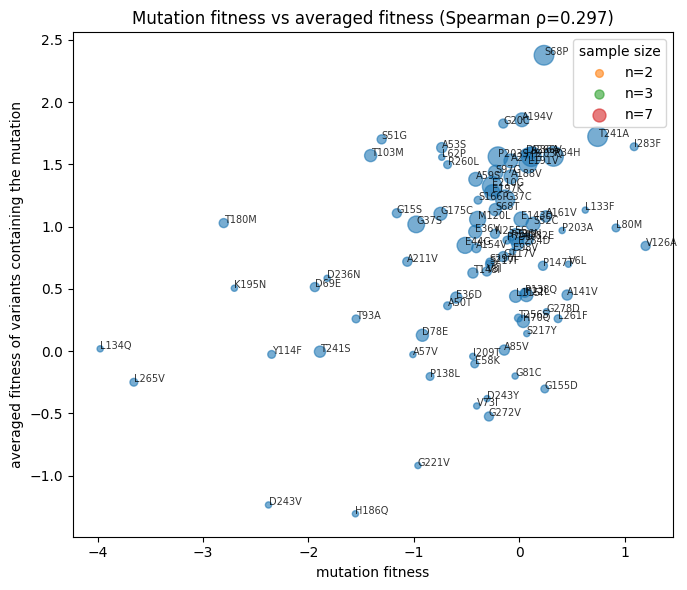

In [ ]:

# --- assume these already exist ---
# point_mut_dic: {mut: fitness_of_mut}
# point_mut_average_effect_dic: {mut: avg_fitness_of_variants_containing_mut}
# point_mut_sample_size_dic: {mut: n_variants_containing_mut}

# --- align by shared keys ---
keys = sorted(set(point_mut_dic) & set(point_mut_average_effect_dic) & set(point_mut_sample_size_dic))

x = np.array([point_mut_dic[k] for k in keys], dtype=float)
y = np.array([point_mut_average_effect_dic[k] for k in keys], dtype=float)
n = np.array([point_mut_sample_size_dic[k] for k in keys], dtype=float)

rho, _ = spearmanr(x, y)

# --- map sample size -> marker size (area) ---
# keeps sizes reasonable and avoids huge bubbles
n_clip = np.clip(n, 1, np.percentile(n, 95))
s = 20 + 180 * (n_clip - n_clip.min()) / (n_clip.max() - n_clip.min() + 1e-12)  # [20..200]

plt.figure(figsize=(7, 6))
plt.scatter(x, y, s=s, alpha=0.6)
plt.xlabel("mutation fitness")
plt.ylabel("averaged fitness of variants containing the mutation")
plt.title(f"Mutation fitness vs averaged fitness (Spearman ρ={rho:.3f})")

# optional: label points (can get crowded; comment out if too many)
for k, xi, yi in zip(keys, x, y):
    plt.annotate(k, (xi, yi), fontsize=7, alpha=0.8)

# optional: show a simple bubble-size legend
for lvl in np.unique(np.quantile(n, [0.25, 0.5, 0.75]).astype(int)):
    lvl = max(lvl, 1)
    lvl_s = 20 + 180 * (np.clip(lvl, 1, np.percentile(n, 95)) - n_clip.min()) / (n_clip.max() - n_clip.min() + 1e-12)
    plt.scatter([], [], s=lvl_s, alpha=0.6, label=f"n={lvl}")
plt.legend(title="sample size", loc="best", frameon=True)

plt.tight_layout()
plt.show()

# Plot epistatic effect

Text(0.5, 1.0, 'Real fitness vs linear model (Spearman ρ=0.350) Sample size: 5786')

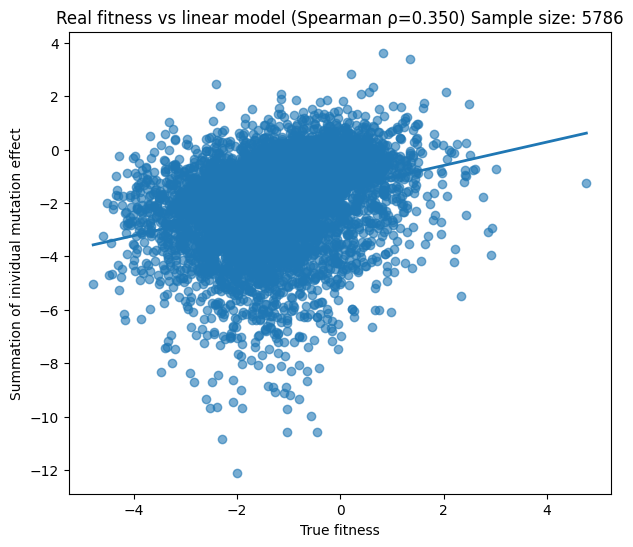

In [ ]:
def all_in(muts, dic):
    for mut in muts:
        if mut not in dic:
            return False
    return True
def compute_sum(muts, dic):
    sum_effect = 0.0
    for mut in muts:
        sum_effect += dic[mut]
    return sum_effect

x,y = [],[]
df_pos = df[df[fitness_name] > threshold_pos].reset_index(drop=True)
for i in range(len(df_pos)):
    if df_pos.loc[i, nham_aa_name] <= 1:
        continue
    muts = df_pos.loc[i, variant_name].split(variant_split_symbol)
    if all_in(muts, point_mut_dic):
        y.append(compute_sum(muts, point_mut_dic))
        x.append(df_pos.loc[i, fitness_name])
x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
rho, _ = spearmanr(x, y)

m, b = np.polyfit(x, y, deg=1)
xx = np.linspace(x.min(), x.max(), 200)
yy = m * xx + b

plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6)
plt.plot(xx, yy, linewidth=2, label=f"fit: y = {m:.3f}x + {b:.3f}")
plt.xlabel("True fitness")
plt.ylabel("Summation of inividual mutation effect")
plt.title(f"Real fitness vs linear model (Spearman ρ={rho:.3f}) Sample size: {len(x)}")